In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
salary_data = pd.read_csv("salary_data.csv")
salary_data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
X = salary_data['YearsExperience'].values
y = salary_data['Salary'].values

In [ ]:
X_mean = np.mean(X)
X_std = np.std(X)
X_scaled = (X - X_mean) / X_std

In [ ]:
theta0 = 0
theta1 = 0

In [ ]:
learning_rate = 0.01
epochs = 500

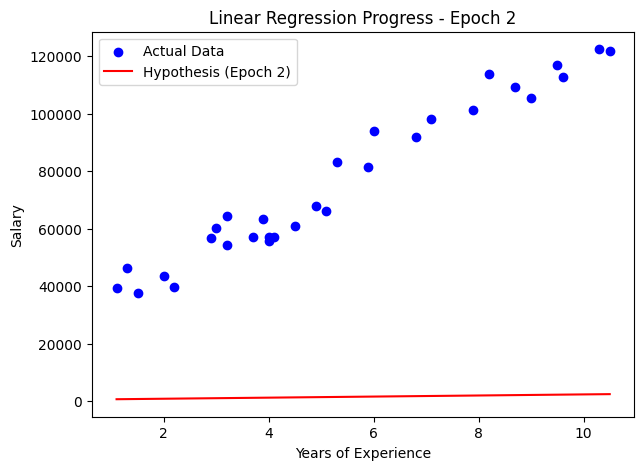

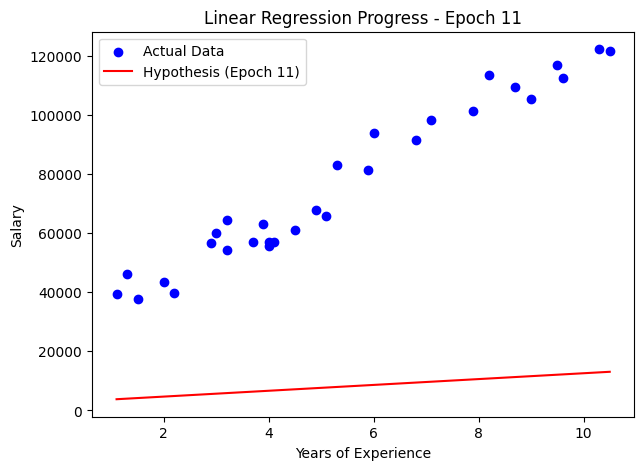

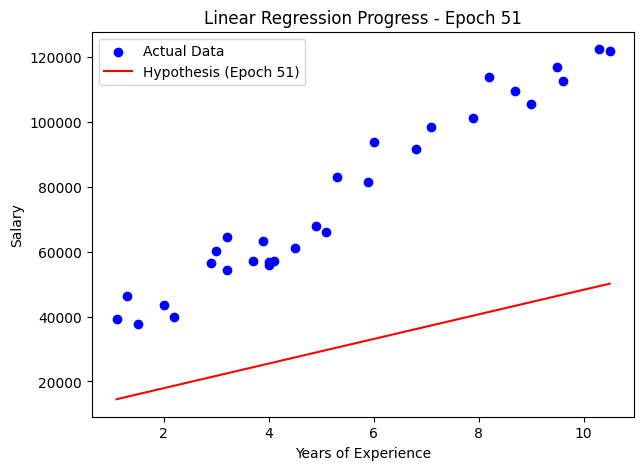

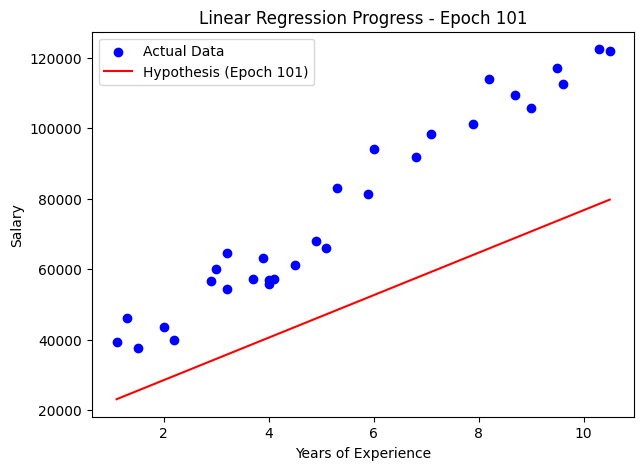

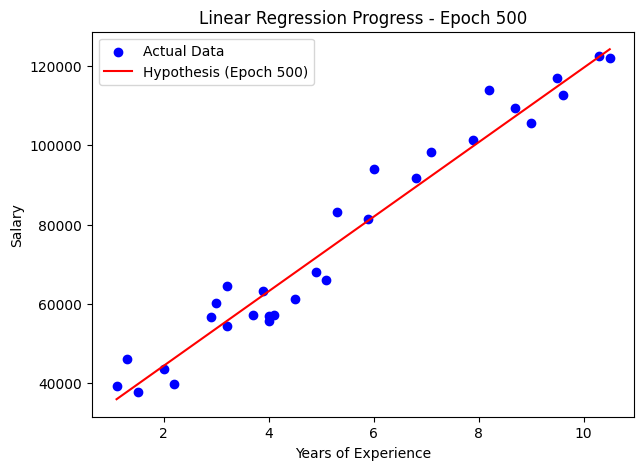

Final Parameters: θ₀ = 75503.6236, θ₁ = 26193.9373


In [ ]:
n = len(X_scaled)
cost_history = []

def compute_cost(X, y, t0, t1):
    predictions = t0 + t1 * X
    return np.mean((predictions - y) ** 2) / 2

for epoch in range(epochs):
    y_pred = theta0 + theta1 * X_scaled
    d_theta0 = np.sum(y_pred - y) / n
    d_theta1 = np.sum((y_pred - y) * X_scaled) / n

    theta0 -= learning_rate * d_theta0
    theta1 -= learning_rate * d_theta1

    cost = compute_cost(X_scaled, y, theta0, theta1)
    cost_history.append(cost)

    if epoch in [1, 10, 50, 100, 500 - 1]:
        plt.figure(figsize=(7, 5))
        plt.scatter(X, y, color='blue', label='Actual Data')
        plt.plot(X, theta0 + theta1 * X_scaled, color='red', label=f'Hypothesis (Epoch {epoch+1})')
        plt.xlabel('Years of Experience')
        plt.ylabel('Salary')
        plt.title(f'Linear Regression Progress - Epoch {epoch+1}')
        plt.legend()
        plt.show()

print(f"Final Parameters: θ₀ = {theta0:.4f}, θ₁ = {theta1:.4f}")

In [ ]:
y_pred_final = theta0 + theta1 * X_scaled

mae = np.mean(np.abs(y - y_pred_final))
mse = np.mean((y - y_pred_final) ** 2)
rmse = np.sqrt(mse)
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_pred_final) ** 2)
r2 = 1 - (ss_res / ss_total)

print("\n📊 MODEL EVALUATION METRICS:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")



📊 MODEL EVALUATION METRICS:
Mean Absolute Error (MAE): 4641.37
Mean Squared Error (MSE): 31550342.41
Root Mean Squared Error (RMSE): 5616.97
R² Score: 0.9566


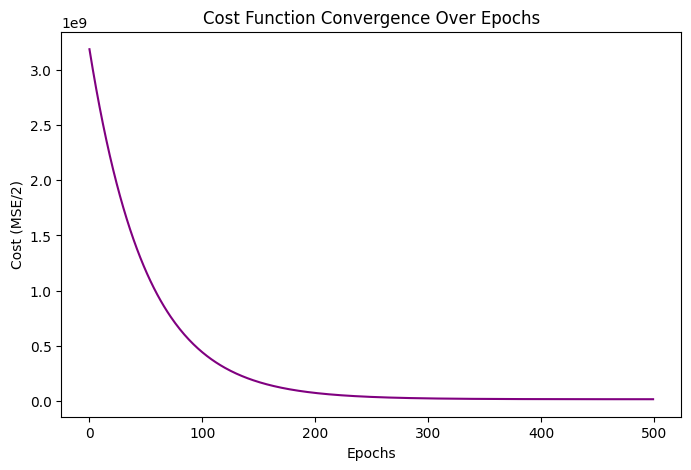

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), cost_history, color='purple')
plt.title("Cost Function Convergence Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE/2)")
plt.show()